# Features temporais e agregações

**Tema:** Preparação de Dados › Feature Engineering

Este notebook constrói encoding cíclico, features de defasagem (lag),
médias móveis e agregações por cliente — e, ponto central do módulo,
demonstra na prática como o vazamento temporal infla artificialmente o
desempenho de um modelo, e como evitá-lo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(44)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Encoding cíclico: hora do dia sem "quebrar" a meia-noite

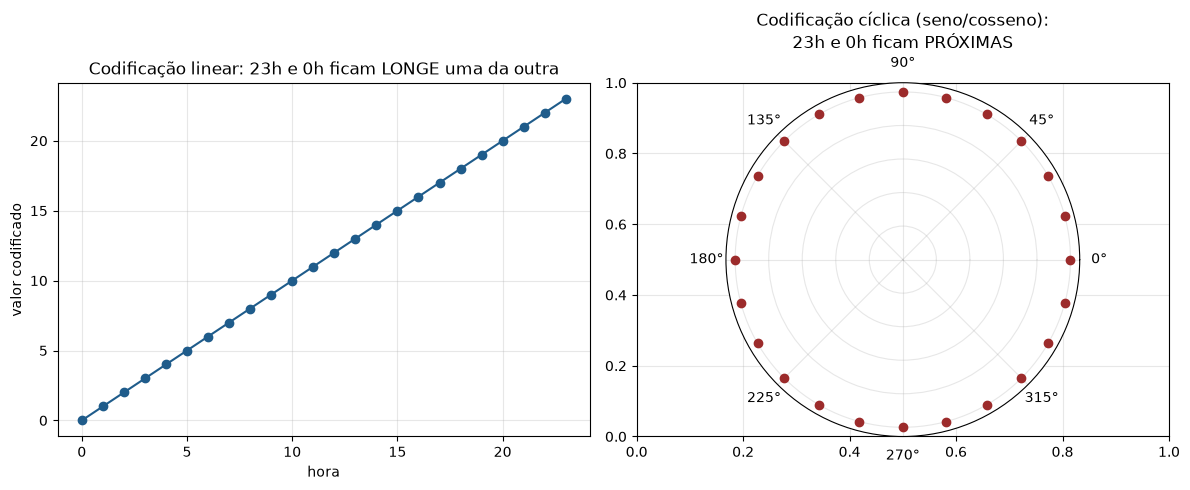

distância linear entre hora 23 e hora 0 : 23
distância cíclica (seno/cosseno) entre hora 23 e hora 0: 0.2611


In [2]:
horas = np.arange(24)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(horas, horas, "o-", color=AZUL)
axes[0].set_title("Codificação linear: 23h e 0h ficam LONGE uma da outra")
axes[0].set_xlabel("hora"); axes[0].set_ylabel("valor codificado")

seno = np.sin(2 * np.pi * horas / 24)
cosseno = np.cos(2 * np.pi * horas / 24)
axes[1] = plt.subplot(1, 2, 2, projection="polar")
angulos = 2 * np.pi * horas / 24
axes[1].plot(angulos, np.ones_like(horas), "o", color=VERMELHO)
for h in [0, 6, 12, 18, 23]:
    axes[1].annotate(f"{h}h", (angulos[h], 1.15), ha="center")
axes[1].set_title("Codificação cíclica (seno/cosseno):\n23h e 0h ficam PRÓXIMAS")
axes[1].set_yticklabels([])
plt.tight_layout(); plt.show()

print(f"distância linear entre hora 23 e hora 0 : {abs(23 - 0)}")
dist_ciclica = np.sqrt((seno[23]-seno[0])**2 + (cosseno[23]-cosseno[0])**2)
print(f"distância cíclica (seno/cosseno) entre hora 23 e hora 0: {dist_ciclica:.4f}")

## 2. Construindo features de defasagem SEM vazar o futuro

Uma série de vendas diárias. A regra: toda média móvel usa `shift(1)`
**antes** de `rolling()` — garantindo que o valor do próprio dia nunca entra
na sua própria feature.

In [3]:
n_dias = 400
tendencia = np.linspace(100, 180, n_dias)
sazonalidade_semanal = 15 * np.sin(2 * np.pi * np.arange(n_dias) / 7)
vendas = tendencia + sazonalidade_semanal + rng.normal(0, 8, n_dias)

serie = pd.DataFrame({"dia": np.arange(n_dias), "vendas": vendas})

# CORRETO: shift(1) antes de rolling -> a janela nunca inclui o dia atual
serie["lag_1"] = serie["vendas"].shift(1)
serie["media_movel_7_correta"] = serie["vendas"].shift(1).rolling(7).mean()

# ERRADO (didático): rolling sem shift inclui o próprio dia na média
serie["media_movel_7_ERRADA"] = serie["vendas"].rolling(7).mean()

print(serie[["dia", "vendas", "lag_1", "media_movel_7_correta",
            "media_movel_7_ERRADA"]].iloc[5:12].to_string(index=False))

 dia     vendas      lag_1  media_movel_7_correta  media_movel_7_ERRADA
   5  91.010240 100.887700                    NaN                   NaN
   6  86.442171  91.010240                    NaN            105.213519
   7  93.252520  86.442171             105.213519            102.597064
   8 116.340833  93.252520             102.597064            103.110552
   9 112.332754 116.340833             103.110552            102.352525
  10 115.131148 112.332754             102.352525            102.199624
  11  97.387293 115.131148             102.199624            101.699566


Repare na linha do dia 10: `media_movel_7_ERRADA` usa `vendas` do próprio dia
10 dentro da média — o modelo teria acesso, de forma disfarçada, ao valor que
está tentando prever. `media_movel_7_correta` usa só os dias 3 a 9.

## 3. Medindo o efeito do vazamento no desempenho de um modelo

Vamos prever `vendas` a partir das features, comparando a versão correta com
a vazada, usando `TimeSeriesSplit` (o método correto de validação temporal,
aprofundado no tema 7).

In [4]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

dados_modelo = serie.dropna().reset_index(drop=True)
y = dados_modelo["vendas"].to_numpy()

X_correto = dados_modelo[["lag_1", "media_movel_7_correta"]].to_numpy()
X_vazado = dados_modelo[["lag_1", "media_movel_7_ERRADA"]].to_numpy()

tscv = TimeSeriesSplit(n_splits=5)


def avalia_temporal(X, y):
    erros = []
    for treino_idx, teste_idx in tscv.split(X):
        modelo = LinearRegression().fit(X[treino_idx], y[treino_idx])
        pred = modelo.predict(X[teste_idx])
        erros.append(mean_absolute_error(y[teste_idx], pred))
    return np.mean(erros)


mae_correto = avalia_temporal(X_correto, y)
mae_vazado = avalia_temporal(X_vazado, y)

print(f"MAE com feature CORRETA (sem vazamento): {mae_correto:.3f}")
print(f"MAE com feature VAZADA (com vazamento) : {mae_vazado:.3f}")
print(f"\nA versão vazada parece {(1 - mae_vazado/mae_correto):.0%} melhor — mas essa")
print("melhora desaparece (ou pior, o modelo falha) em produção, porque no")
print("momento real da previsão o valor do próprio dia ainda não existe.")

MAE com feature CORRETA (sem vazamento): 10.582
MAE com feature VAZADA (com vazamento) : 10.127

A versão vazada parece 4% melhor — mas essa
melhora desaparece (ou pior, o modelo falha) em produção, porque no
momento real da previsão o valor do próprio dia ainda não existe.


## 4. Agregações por entidade: histórico de cliente sem vazamento

Cada cliente tem várias transações ao longo do tempo. Para cada transação,
queremos `n_compras_antes_desta` e `ticket_medio_antes_desta` — calculados
usando **só** transações anteriores àquela linha.

In [5]:
n_clientes = 200
transacoes = []
for cliente_id in range(n_clientes):
    n_trans = rng.integers(3, 15)
    dias = np.sort(rng.choice(np.arange(200), n_trans, replace=False))
    valores = rng.lognormal(np.log(100), 0.5, n_trans)
    for dia, valor in zip(dias, valores):
        transacoes.append({"cliente_id": cliente_id, "dia": dia, "valor": valor})

df_trans = pd.DataFrame(transacoes).sort_values(["cliente_id", "dia"]).reset_index(drop=True)

# CORRETO: agregação usando expanding().shift para excluir a própria linha
df_trans["n_compras_antes"] = df_trans.groupby("cliente_id").cumcount()
df_trans["ticket_medio_antes"] = (
    df_trans.groupby("cliente_id")["valor"]
    .apply(lambda s: s.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)

print(df_trans[df_trans["cliente_id"] == 0]
      [["dia", "valor", "n_compras_antes", "ticket_medio_antes"]].to_string(index=False))

 dia      valor  n_compras_antes  ticket_medio_antes
  10  85.971023                0                 NaN
  63 141.717356                1           85.971023
 105  93.602692                2          113.844190
 113 120.077568                3          107.097024


Na primeira transação de cada cliente, `n_compras_antes = 0` e
`ticket_medio_antes` é nulo (não existe histórico ainda) — o comportamento
correto. Preencher esse nulo inicial exige uma decisão de negócio (zero?
média global? é o próprio caso "cliente novo" que talvez mereça uma feature
indicadora, como no módulo 2).

## O que levar deste notebook

- Encoding cíclico (seno/cosseno) preserva a proximidade real entre horas e
  dias da semana perto do início/fim do ciclo.
- Toda feature de defasagem ou média móvel deve ser calculada com
  `shift(1)` antes da agregação — nunca incluindo o próprio ponto.
- O vazamento temporal infla o desempenho medido de forma enganosa: o
  ganho "some" (ou pior, vira erro real) assim que o modelo roda em
  produção, onde o futuro genuinamente não existe ainda.
- Agregações por entidade (histórico de cliente) seguem a mesma regra:
  exclua a própria linha do cálculo do "histórico até aqui".

→ Próximo: **Seleção de features**, filtro/wrapper/embutido, para decidir o
que fazer com o conjunto de features já construído.